**AutoEncoder**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mpl.rcParams["figure.figsize"] = (10, 5)
mpl.rcParams["axes.grid"] = False

In [2]:
df = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None )
raw_data = df.values
df.shape

(4998, 141)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [5]:
df

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,0.608558,-0.335651,-0.990948,-1.784153,-2.626145,-2.957065,-2.931897,-2.664816,-2.090137,-1.461841,...,1.757705,2.291923,2.704595,2.451519,2.017396,1.704358,1.688542,1.629593,1.342651,0.0
4994,-2.060402,-2.860116,-3.405074,-3.748719,-3.513561,-3.006545,-2.234850,-1.593270,-1.075279,-0.976047,...,1.388947,2.079675,2.433375,2.159484,1.819747,1.534767,1.696818,1.483832,1.047612,0.0
4995,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,-0.645363,...,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334,0.0
4996,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,-1.374321,...,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932,0.0


In [7]:
df = df.add_prefix('c')
df['c0'].value_counts()

c0
-0.112522    1
-1.100878    1
-0.567088    1
 0.490473    1
 0.800232    1
            ..
 0.608558    1
-2.060402    1
-1.122969    1
-0.547705    1
-1.351779    1
Name: count, Length: 4998, dtype: int64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(df.values, df.values[:, 0:1], test_size = 0.2, random_state = 111) 

In [9]:
scaler = MinMaxScaler()
data_scaled = scaler.fit(x_train)
train_data_scaled = data_scaled.transform(x_train)
test_data_scaled = data_scaled.transform(x_test)

In [10]:
normal_train_data = pd.DataFrame(train_data_scaled).add_prefix('c').query('c0 == 0').values[:,1:]
anomaly_train_data = pd.DataFrame(train_data_scaled).add_prefix('c').query('c0 > 0').values[:,1:]
normal_test_data = pd.DataFrame(test_data_scaled).add_prefix('c').query('c0 == 0').values[:,1:]
anomaly_test_data = pd.DataFrame(test_data_scaled).add_prefix('c').query('c0 > 0').values[:,1:]

IndexError: index 1 is out of bounds for axis 0 with size 1

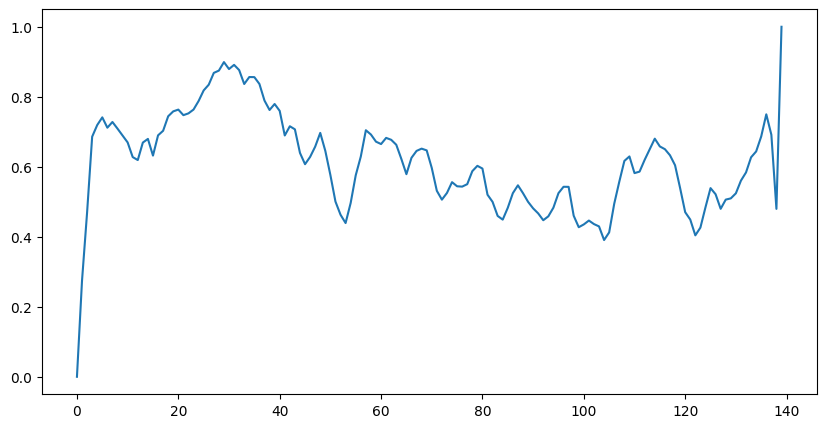

In [11]:
plt.plot(normal_train_data[0])
plt.plot(normal_train_data[1])
plt.plot(normal_train_data[2])
plt.title("Normal Data")
plt.show()

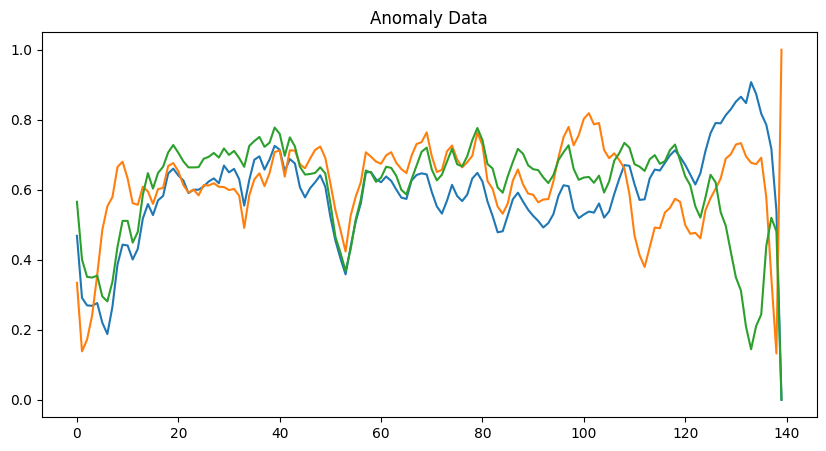

In [12]:
plt.plot(anomaly_train_data[0])
plt.plot(anomaly_train_data[1])
plt.plot(anomaly_train_data[2])
plt.title("Anomaly Data")
plt.show()

In [13]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(64, activation= 'relu'))
model.add(tf.keras.layers.Dense(32, activation= 'relu'))
model.add(tf.keras.layers.Dense(16, activation= 'relu'))
model.add(tf.keras.layers.Dense(8, activation= 'relu'))
model.add(tf.keras.layers.Dense(16, activation= 'relu'))
model.add(tf.keras.layers.Dense(32, activation= 'relu'))
model.add(tf.keras.layers.Dense(64, activation= 'relu'))
model.add(tf.keras.layers.Dense(149, activation= 'sigmoid'))

In [16]:
class AutoEncoder(Model):
    def __init__ (self):
        super(AutoEncoder, self).__init__()
        self.encoder = tf.keras.Sequential([
                       tf.keras.layers.Dense(64, activation= 'relu'),
                        tf.keras.layers.Dense(32, activation= 'relu'),
                        tf.keras.layers.Dense(16, activation= 'relu'),
                        tf.keras.layers.Dense(8, activation= 'relu')
                    ])
        self.decoder = tf.keras.Sequential([
                       tf.keras.layers.Dense(16, activation= 'relu'),
                        tf.keras.layers.Dense(32, activation= 'relu'),
                        tf.keras.layers.Dense(64, activation= 'relu'),
                        tf.keras.layers.Dense(140, activation= 'relu')
                    ])

    def call (self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [21]:
model = AutoEncoder()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    mode="min"
)

model.compile(optimizer="adam", loss="mae")

history = model.fit(
    normal_train_data,
    normal_train_data,
    epochs=50,
    batch_size=120,
    validation_data=(train_data_scaled[:, 1:], train_data_scaled[:, 1:]),
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.6043 - val_loss: 0.5903
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 0.5958 - val_loss: 0.5814
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.5859 - val_loss: 0.5714
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.5759 - val_loss: 0.5601
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.5642 - val_loss: 0.5468
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.5506 - val_loss: 0.5321
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.5351 - val_loss: 0.5156
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 0.5177 - val_loss: 0.4972
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 0.4979 - val_loss: 0.4769
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.4750 - val_loss: 0.4543
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 0.4522 - val_loss: 0.4310
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 0.4300 - val_loss:

In [20]:
encoder_out = model.encoder(normal_test_data).numpy()# 8 unit representation of data
decoder_out = model.decoder(encoder_out).numpy()

In [28]:
plt.plot(normal_test_data[0], 'b')
plt.plot(decoder_out[0], 'r')
plt.title("Model performance on Normal data")
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

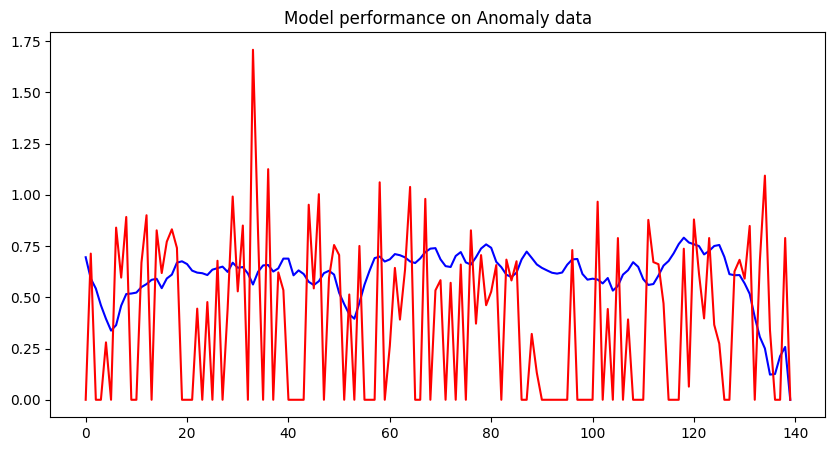

In [29]:
encoder_out = model.encoder(anomaly_test_data).numpy()# 8 unit representation of data
decoder_out = model.decoder(encoder_out).numpy() 
plt.plot(anomaly_test_data[0], 'b')
plt.plot(decoder_out[0], 'r')
plt.title("Model performance on Anomaly data")
plt.show()

In [30]:
reconstruction = model.predict(normal_test_data)
threshold = np.mean(train_loss) + 2 * np.std(train_loss)
reconstruction_a = model.predict(anomaly_test_data)

train_loss = tf.keras.losses.mae(reconstruction, normal_test_data)
train_loss_a = tf.keras.losses.mae(reconstruction_a, anomaly_test_data)
plt.hist(train_loss, bins=50, label='normal')
plt.hist(train_loss_a, bins=50, label='anomaly')

plt.axvline(
    threshold,
    color='r',
    linewidth=3,
    linestyle='dashed',
    label="{:.3f}".format(threshold)
)

plt.legend(loc='upper right')
plt.title("Normal and Anomaly Loss")
plt.show()

C:\Users\oyelola Ibrahim\Desktop\my deep learning project\ANN_with_MNISTDATA\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


ValueError: math domain error